<a href="https://colab.research.google.com/github/jaeheechillin3/pytorch_projects/blob/main/unet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Imports and configuration

In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import OxfordIIITPet
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

In [8]:
SEED = 42
IMAGE_SIZE = (160, 160)
BATCH_SIZE = 8
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4
NUM_CLASSES = 3
CHECKPOINT_PATH = "/content/best_unet_pet.pth"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

if device.type == "cuda":
    torch.backends.cudnn.benchmark = True

Device: cuda


## Dataset

In [9]:
class PetSegmentationDataset(Dataset):
    def __init__(self, base_dataset, indices=None, augment=False):
        self.base_dataset = base_dataset
        self.indices = (
            list(range(len(base_dataset)))
            if indices is None
            else list(indices)
        )
        self.augment = augment

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, index):
        image, mask = self.base_dataset[self.indices[index]]

        # Apply the same random flip to image and mask
        if self.augment and random.random() < 0.5:
            image = TF.hflip(image)
            mask = TF.hflip(mask)

        image = TF.resize(
            image,
            IMAGE_SIZE,
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        # Nearest-neighbor is essential for segmentation masks
        mask = TF.resize(
            mask,
            IMAGE_SIZE,
            interpolation=InterpolationMode.NEAREST,
        )

        image = TF.to_tensor(image)
        image = TF.normalize(
            image,
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
        )

        # Dataset mask values are 1, 2, 3.
        # CrossEntropyLoss expects class labels 0, 1, 2.
        mask = torch.from_numpy(np.array(mask, dtype=np.int64)) - 1

        return image, mask


# Download original datasets
trainval_base = OxfordIIITPet(
    root="/content/data",
    split="trainval",
    target_types="segmentation",
    download=True,
)

test_base = OxfordIIITPet(
    root="/content/data",
    split="test",
    target_types="segmentation",
    download=True,
)

# Reproducible 90/10 train-validation split
generator = torch.Generator().manual_seed(SEED)
indices = torch.randperm(len(trainval_base), generator=generator).tolist()

train_size = int(0.9 * len(indices))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_dataset = PetSegmentationDataset(
    trainval_base, train_indices, augment=True
)
val_dataset = PetSegmentationDataset(
    trainval_base, val_indices, augment=False
)
test_dataset = PetSegmentationDataset(
    test_base, augment=False
)

loader_options = {
    "batch_size": BATCH_SIZE,
    "num_workers": 0,
    "pin_memory": device.type == "cuda",
}

train_loader = DataLoader(
    train_dataset,
    shuffle=True,
    **loader_options,
)

val_loader = DataLoader(
    val_dataset,
    shuffle=False,
    **loader_options,
)

test_loader = DataLoader(
    test_dataset,
    shuffle=False,
    **loader_options,
)

print(
    f"Train: {len(train_dataset)}, "
    f"Validation: {len(val_dataset)}, "
    f"Test: {len(test_dataset)}"
)


Train: 3312, Validation: 368, Test: 3669


## Defining the model

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels,
                kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels, out_channels,
                kernel_size=3, padding=1, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.conv(x)


class UNET(nn.Module):
    def __init__(
        self,
        in_channels=3,
        out_channels=3,
        features=(64, 128, 256, 512),
    ):
        super().__init__()

        self.downs = nn.ModuleList()
        self.ups = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        for feature in features:
            self.downs.append(DoubleConv(in_channels, feature))
            in_channels = feature

        self.bottleneck = DoubleConv(
            features[-1], features[-1] * 2
        )

        for feature in reversed(features):
            self.ups.append(
                nn.ConvTranspose2d(
                    feature * 2,
                    feature,
                    kernel_size=2,
                    stride=2,
                )
            )
            self.ups.append(DoubleConv(feature * 2, feature))

        self.final_conv = nn.Conv2d(
            features[0], out_channels, kernel_size=1
        )

    def forward(self, x):
        skip_connections = []

        for down in self.downs:
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for index in range(0, len(self.ups), 2):
            x = self.ups[index](x)
            skip = skip_connections[index // 2]

            if x.shape[2:] != skip.shape[2:]:
                x = F.interpolate(
                    x,
                    size=skip.shape[2:],
                    mode="bilinear",
                    align_corners=False,
                )

            x = torch.cat((skip, x), dim=1)
            x = self.ups[index + 1](x)

        return self.final_conv(x)


model = UNET(
    in_channels=3,
    out_channels=NUM_CLASSES,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=2,
    factor=0.5,
)

## Training and evaluation

In [11]:
def train_one_epoch(loader):
    model.train()
    total_loss = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, masks in progress:
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        logits = model(images)
        loss = criterion(logits, masks)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        progress.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(loader):
    model.eval()

    total_loss = 0
    confusion_matrix = torch.zeros(
        NUM_CLASSES,
        NUM_CLASSES,
        dtype=torch.float64,
        device=device,
    )

    for images, masks in tqdm(loader, desc="Evaluating", leave=False):
        images = images.to(device, non_blocking=True)
        masks = masks.to(device, non_blocking=True)

        logits = model(images)
        loss = criterion(logits, masks)
        predictions = logits.argmax(dim=1)

        total_loss += loss.item() * images.size(0)

        encoded = (
            NUM_CLASSES * masks.reshape(-1)
            + predictions.reshape(-1)
        )

        confusion_matrix += torch.bincount(
            encoded,
            minlength=NUM_CLASSES ** 2,
        ).reshape(NUM_CLASSES, NUM_CLASSES)

    intersection = confusion_matrix.diag()
    target_pixels = confusion_matrix.sum(dim=1)
    predicted_pixels = confusion_matrix.sum(dim=0)

    union = target_pixels + predicted_pixels - intersection
    dice_denominator = target_pixels + predicted_pixels

    valid_iou = union > 0
    valid_dice = dice_denominator > 0

    mean_iou = (intersection[valid_iou] / union[valid_iou]).mean()
    mean_dice = (
        2 * intersection[valid_dice]
        / dice_denominator[valid_dice]
    ).mean()

    average_loss = total_loss / len(loader.dataset)

    return (
        average_loss,
        mean_iou.item(),
        mean_dice.item(),
    )


history = {
    "train_loss": [],
    "val_loss": [],
    "val_iou": [],
    "val_dice": [],
}

best_iou = -1

for epoch in range(NUM_EPOCHS):
    train_loss = train_one_epoch(train_loader)
    val_loss, val_iou, val_dice = evaluate(val_loader)

    scheduler.step(val_loss)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_iou"].append(val_iou)
    history["val_dice"].append(val_dice)

    print(
        f"Epoch {epoch + 1:02d}/{NUM_EPOCHS} | "
        f"train loss: {train_loss:.4f} | "
        f"val loss: {val_loss:.4f} | "
        f"val IoU: {val_iou:.4f} | "
        f"val Dice: {val_dice:.4f}"
    )

    if val_iou > best_iou:
        best_iou = val_iou
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print("Saved new best model")

Training:   0%|          | 0/414 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 01/15 | train loss: 0.6311 | val loss: 0.4727 | val IoU: 0.5882 | val Dice: 0.7159
Saved new best model


Training:   0%|          | 0/414 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 14/15 | train loss: 0.2317 | val loss: 0.2718 | val IoU: 0.7183 | val Dice: 0.8210


Training:   0%|          | 0/414 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/46 [00:00<?, ?it/s]

Epoch 15/15 | train loss: 0.2284 | val loss: 0.2476 | val IoU: 0.7435 | val Dice: 0.8401
Saved new best model


## Load best model and test

In [12]:
model.load_state_dict(
    torch.load(CHECKPOINT_PATH, map_location=device)
)

test_loss, test_iou, test_dice = evaluate(test_loader)

print("\nTest results")
print(f"Loss: {test_loss:.4f}")
print(f"Mean IoU: {test_iou:.4f}")
print(f"Mean Dice: {test_dice:.4f}")

Evaluating:   0%|          | 0/459 [00:00<?, ?it/s]


Test results
Loss: 0.2646
Mean IoU: 0.7387
Mean Dice: 0.8383


## Plot training history


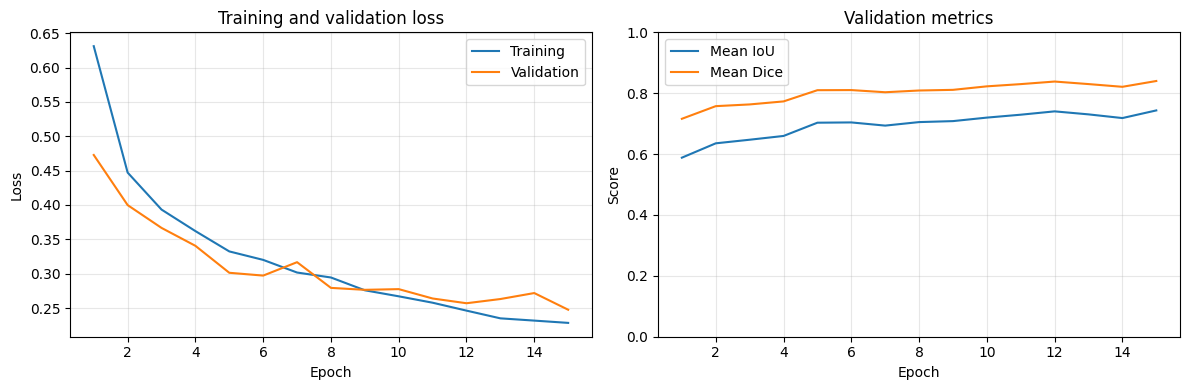

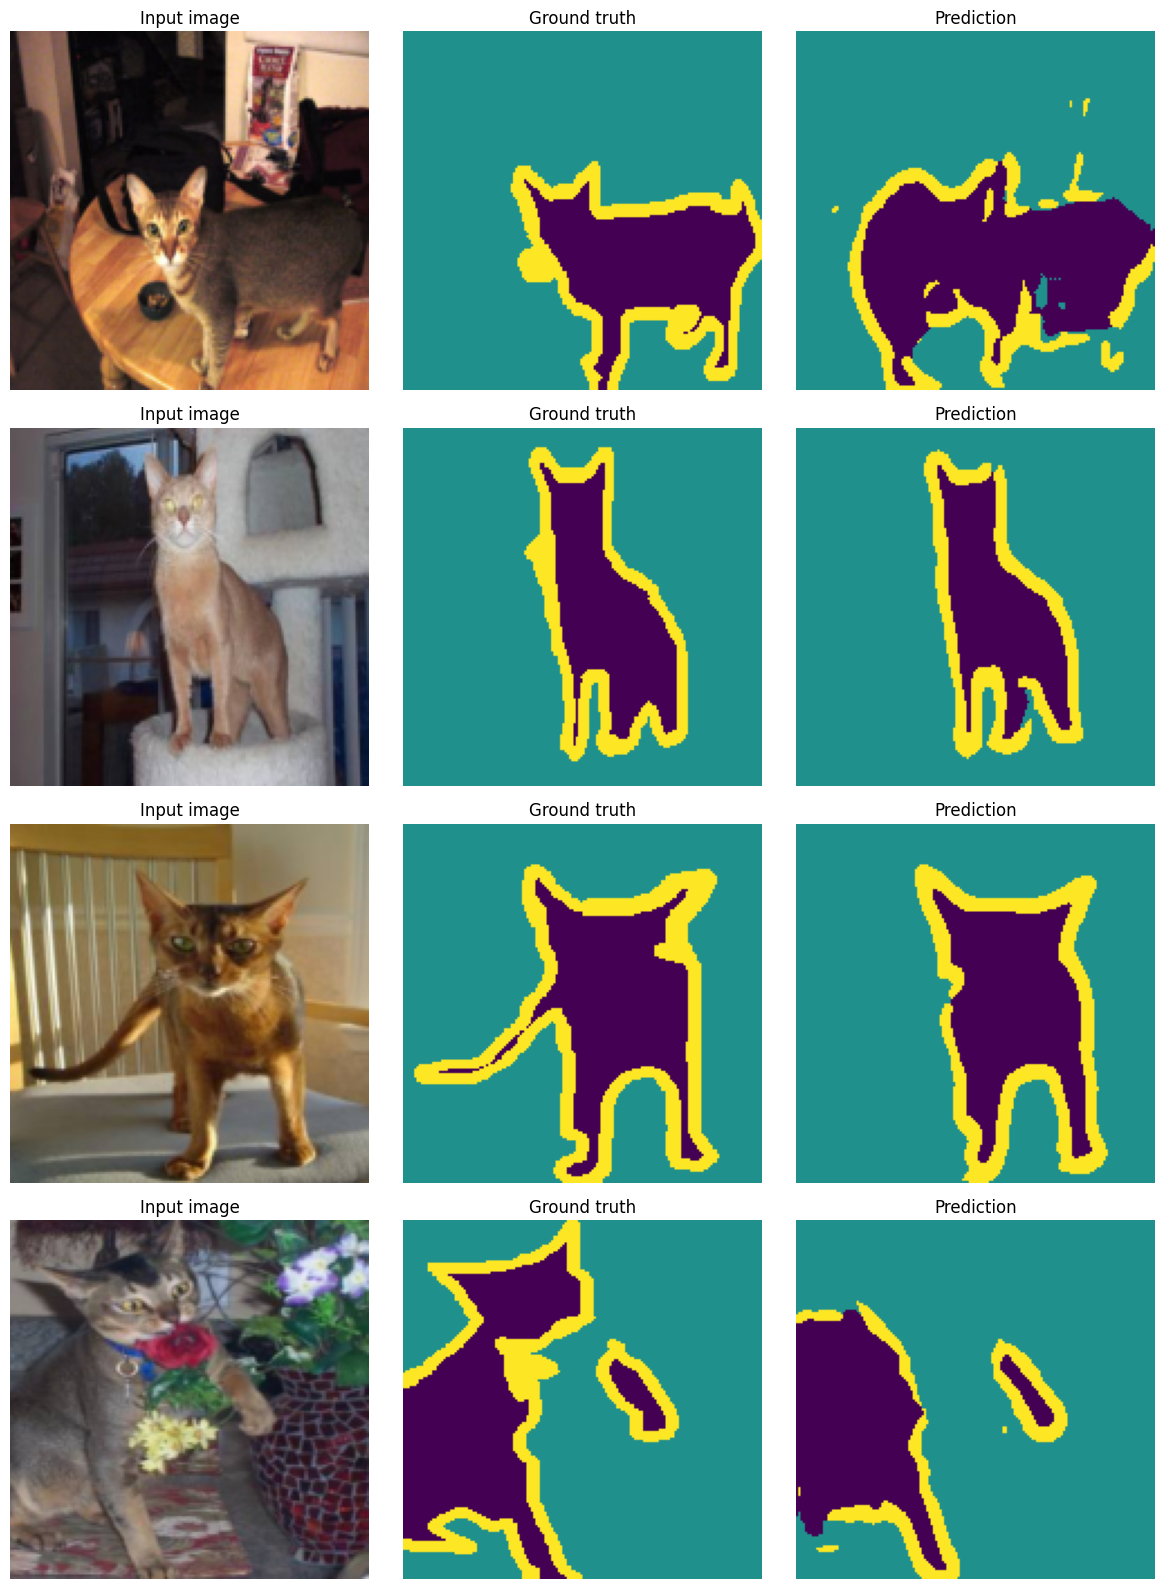

In [13]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="Training")
plt.plot(epochs, history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and validation loss")
plt.legend()
plt.grid(alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs, history["val_iou"], label="Mean IoU")
plt.plot(epochs, history["val_dice"], label="Mean Dice")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Validation metrics")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(image):
    return (image.cpu() * STD + MEAN).clamp(0, 1)


@torch.no_grad()
def show_predictions(loader, number_of_images=4):
    model.eval()

    images, masks = next(iter(loader))
    images_device = images.to(device)

    predictions = model(images_device).argmax(dim=1).cpu()

    number_of_images = min(number_of_images, len(images))

    plt.figure(figsize=(12, 4 * number_of_images))

    for i in range(number_of_images):
        image = denormalize(images[i]).permute(1, 2, 0)

        plt.subplot(number_of_images, 3, i * 3 + 1)
        plt.imshow(image)
        plt.title("Input image")
        plt.axis("off")

        plt.subplot(number_of_images, 3, i * 3 + 2)
        plt.imshow(masks[i], cmap="viridis", vmin=0, vmax=2)
        plt.title("Ground truth")
        plt.axis("off")

        plt.subplot(number_of_images, 3, i * 3 + 3)
        plt.imshow(predictions[i], cmap="viridis", vmin=0, vmax=2)
        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


show_predictions(test_loader, number_of_images=4)